# Understanding Mamba: A Transformer Alternative for the Impatient

## For people who know Transformers but find Mamba confusing

If you've implemented GPT-2 from scratch but feel lost reading about Mamba, this notebook is for you.

**What you'll understand by the end:**
- Why Transformers are slow for long sequences (you probably know this)
- The ONE key idea that makes Mamba work
- How Mamba achieves "attention-like" selectivity without O(L²) cost
- When to use Mamba vs Transformers

**What we'll skip:**
- Formal control theory (not needed for intuition)
- Mathematical proofs (we'll show, not prove)
- Implementation details (we'll focus on the core mechanism)

## Configuration

All hyperparameters in one place.

In [1]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # Visualization
    'seq_lengths': [128, 256, 512, 1024, 2048],  # Sequence lengths to benchmark
    'd_model': 256,  # Model dimension for comparisons
    
    # Models
    'state_size': 64,  # SSM state dimension
    'vocab_size': 50,  # Vocabulary size for toy tasks
    
    # Training (for toy experiments)
    'batch_size': 32,  # Training batch size
    'learning_rate': 0.001,  # Learning rate
    'n_epochs': 100,  # Training epochs
}

## Setup

Import what we need and set random seed.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import time

from aiml_notebooks import set_seed, get_device

%load_ext autoreload
%autoreload 2

set_seed(CONFIG['seed'])
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## 1. The Problem: Attention is O(L²)

You already know this, but let's visualize it clearly.

### Visualizing the attention bottleneck

In self-attention, every token attends to every other token. This creates an L×L matrix.

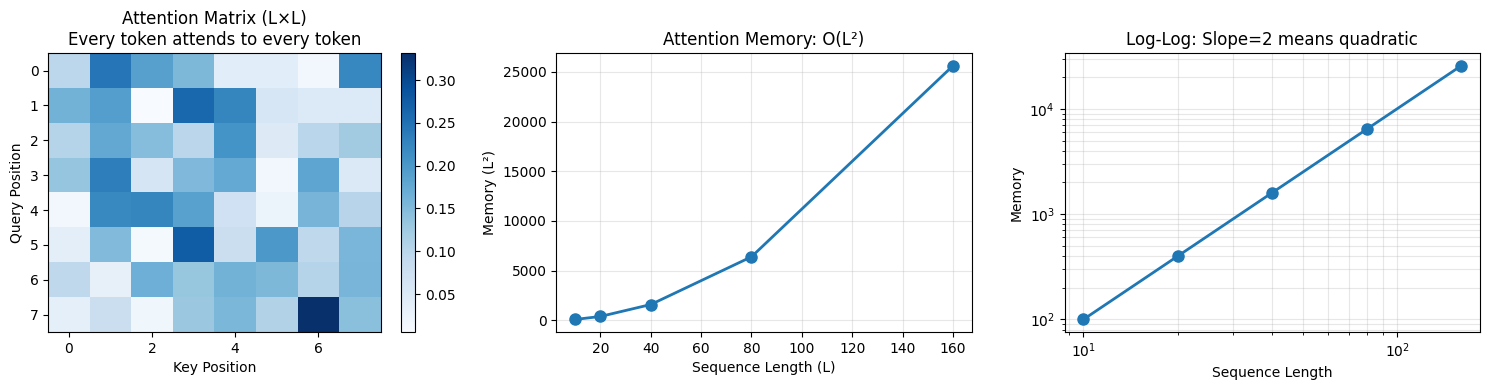

For L=160, attention needs 25,600 elements!
This is why processing entire books is expensive.


In [3]:
# Create a simple attention visualization
seq_len = 8
attention_matrix = np.random.rand(seq_len, seq_len)
attention_matrix = attention_matrix / attention_matrix.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Show attention matrix
im = axes[0].imshow(attention_matrix, cmap='Blues', aspect='auto')
axes[0].set_xlabel('Key Position')
axes[0].set_ylabel('Query Position')
axes[0].set_title('Attention Matrix (L×L)\nEvery token attends to every token')
plt.colorbar(im, ax=axes[0])

# Show quadratic growth
seq_lengths = [10, 20, 40, 80, 160]
memory = [l**2 for l in seq_lengths]
axes[1].plot(seq_lengths, memory, 'o-', linewidth=2, markersize=8)
axes[1].set_xlabel('Sequence Length (L)')
axes[1].set_ylabel('Memory (L²)')
axes[1].set_title('Attention Memory: O(L²)')
axes[1].grid(True, alpha=0.3)

# Log-log plot
axes[2].plot(seq_lengths, memory, 'o-', linewidth=2, markersize=8)
axes[2].set_xlabel('Sequence Length')
axes[2].set_ylabel('Memory')
axes[2].set_title('Log-Log: Slope=2 means quadratic')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"For L={seq_lengths[-1]}, attention needs {memory[-1]:,} elements!")
print(f"This is why processing entire books is expensive.")

## 2. The Dream: Linear Complexity

**What if we could process sequences in O(L) instead of O(L²)?**

Think about reading a book:
- You don't re-read everything you've seen when processing each new word
- You maintain a **compact summary** of what you've read so far
- You update this summary as you go

This is exactly what **recurrent models** do!

### The simplest recurrence: Moving average

Let's build intuition with the simplest possible "memory" - a moving average.

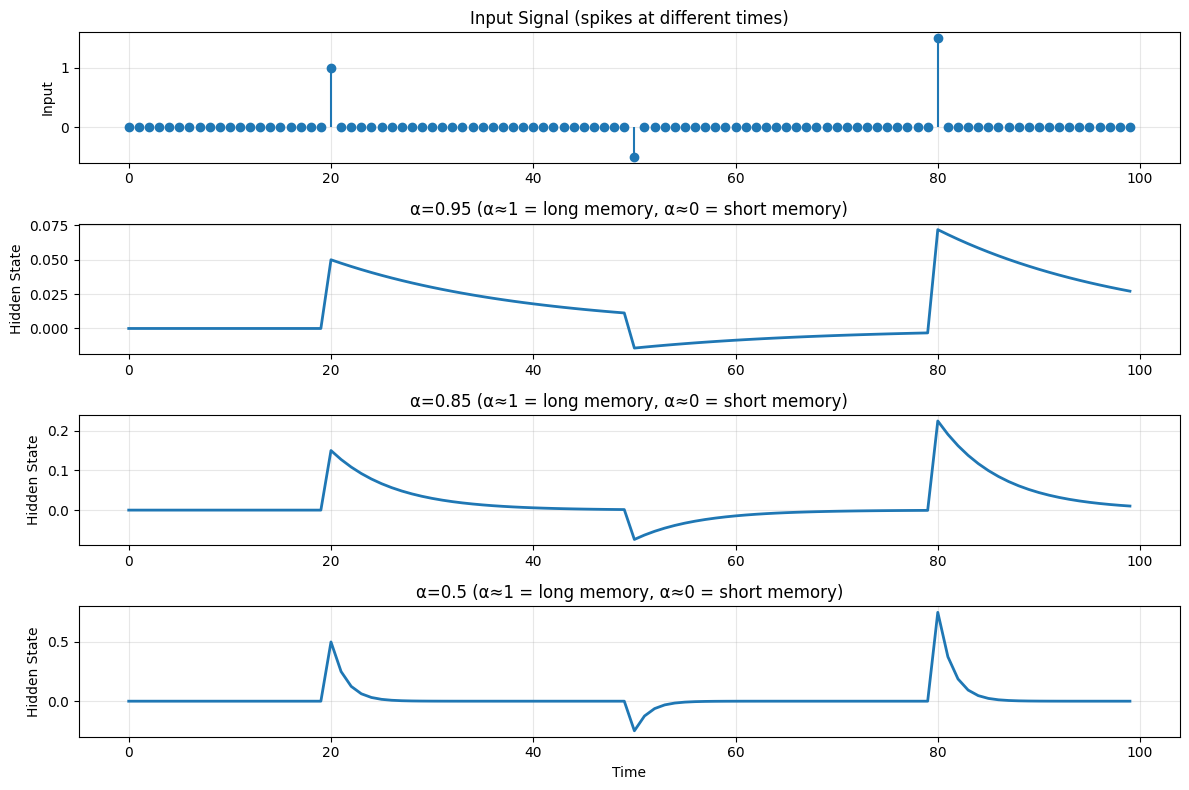

Key insight: α controls HOW LONG we remember things
But α is FIXED - same for all inputs!


In [4]:
def moving_average(x, alpha=0.9):
    """
    Exponential moving average: h_t = alpha * h_{t-1} + (1-alpha) * x_t
    
    This is O(L) - we just update one number at each step!
    """
    h = 0.0
    history = []
    
    for x_t in x:
        h = alpha * h + (1 - alpha) * x_t
        history.append(h)
    
    return np.array(history)

# Create a simple signal
T = 100
x = np.zeros(T)
x[20] = 1.0  # Spike at t=20
x[50] = -0.5  # Negative spike
x[80] = 1.5  # Larger spike

# Try different alpha values
alphas = [0.95, 0.85, 0.5]
fig, axes = plt.subplots(len(alphas) + 1, 1, figsize=(12, 8))

# Input signal
axes[0].stem(x, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].set_ylabel('Input')
axes[0].set_title('Input Signal (spikes at different times)')
axes[0].grid(True, alpha=0.3)

# Moving averages with different memory lengths
for idx, alpha in enumerate(alphas):
    h = moving_average(x, alpha)
    axes[idx + 1].plot(h, linewidth=2)
    axes[idx + 1].set_ylabel('Hidden State')
    axes[idx + 1].set_title(f'α={alpha} (α≈1 = long memory, α≈0 = short memory)')
    axes[idx + 1].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

print("Key insight: α controls HOW LONG we remember things")
print("But α is FIXED - same for all inputs!")

## 3. The Problem with Fixed Memory

A moving average (or any linear recurrence) has a **critical limitation**:

**The "forgetting rate" α is the same for ALL inputs.**

But in real tasks, some things are important to remember, others aren't!

**Example**: When reading code
```python
x = 5          # Remember this!
print("hello") # Don't care
y = x + 3      # Need to remember x!
```

You want to:
- Remember `x = 5` strongly
- Forget `print("hello")` quickly

**Transformers solve this with attention** - they compute which tokens to focus on.

**But attention is O(L²)!**

**Can we get selective memory without quadratic cost?**

## 4. The Mamba Insight: Input-Dependent Forgetting

**Mamba's core idea:**
Make the forgetting rate α depend on the INPUT!

```python
# Fixed recurrence (old way):
h_t = alpha * h_{t-1} + (1-alpha) * x_t

# Selective recurrence (Mamba's way):
alpha_t = f(x_t)  # <-- Compute alpha from input!
h_t = alpha_t * h_{t-1} + (1-alpha_t) * x_t
```

Now the model can **decide** based on content:
- "This is important" → small α → remember longer
- "This is noise" → large α → forget quickly

### Implementing selective memory

Let's see this in action with a toy example.

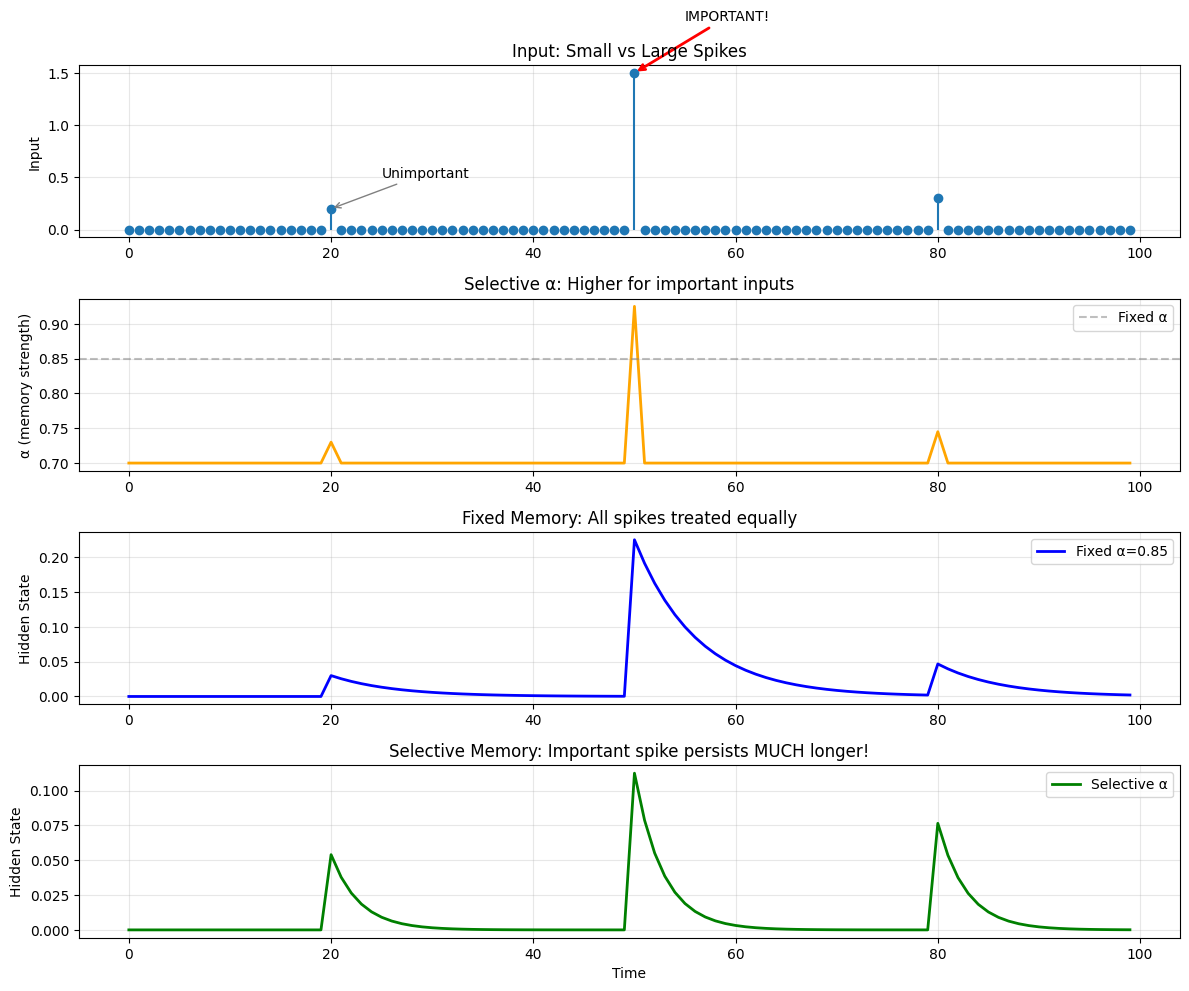


🎯 KEY INSIGHT: Selective memory keeps important info longer
   - Still O(L) complexity (just one state update per step)
   - But now content-aware, like attention!


In [5]:
def selective_moving_average(x, base_alpha=0.9, selectivity=2.0):
    """
    Input-dependent forgetting rate.
    
    Rule: Larger inputs → more important → remember longer (higher alpha)
    """
    h = 0.0
    history = []
    alphas = []
    
    for x_t in x:
        # Make alpha depend on input magnitude
        importance = np.abs(x_t)
        alpha_t = np.clip(base_alpha + selectivity * importance, 0.0, 0.99)
        
        h = alpha_t * h + (1 - alpha_t) * x_t
        history.append(h)
        alphas.append(alpha_t)
    
    return np.array(history), np.array(alphas)

# Create signal with "important" and "unimportant" spikes
T = 100
x = np.zeros(T)
x[20] = 0.2   # Small (unimportant)
x[50] = 1.5   # Large (IMPORTANT!)
x[80] = 0.3   # Small (unimportant)

# Compare fixed vs selective
h_fixed = moving_average(x, alpha=0.85)
h_selective, alphas = selective_moving_average(x, base_alpha=0.7, selectivity=0.15)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Input
axes[0].stem(x, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].set_ylabel('Input')
axes[0].set_title('Input: Small vs Large Spikes')
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Unimportant', xy=(20, 0.2), xytext=(25, 0.5),
                arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].annotate('IMPORTANT!', xy=(50, 1.5), xytext=(55, 2.0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Alpha values (selectivity)
axes[1].plot(alphas, linewidth=2, color='orange')
axes[1].set_ylabel('α (memory strength)')
axes[1].set_title('Selective α: Higher for important inputs')
axes[1].axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, label='Fixed α')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Fixed memory
axes[2].plot(h_fixed, linewidth=2, label='Fixed α=0.85', color='blue')
axes[2].set_ylabel('Hidden State')
axes[2].set_title('Fixed Memory: All spikes treated equally')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Selective memory
axes[3].plot(h_selective, linewidth=2, label='Selective α', color='green')
axes[3].set_ylabel('Hidden State')
axes[3].set_xlabel('Time')
axes[3].set_title('Selective Memory: Important spike persists MUCH longer!')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 KEY INSIGHT: Selective memory keeps important info longer")
print("   - Still O(L) complexity (just one state update per step)")
print("   - But now content-aware, like attention!")

## 5. From Toy Example to Real Mamba

Our toy example showed the core idea, but real Mamba is more sophisticated:

### What we just did (toy):
```python
alpha_t = base_alpha + importance(x_t)
h_t = alpha_t * h_{t-1} + (1-alpha_t) * x_t
```

### What real Mamba does:
```python
# 1. Multi-dimensional state (not just one number)
h_t ∈ ℝ^N  # N-dimensional hidden state

# 2. Input-dependent parameters
A_t = f_A(x_t)  # How to evolve state
B_t = f_B(x_t)  # How much to take from input
C_t = f_C(x_t)  # How to produce output

# 3. Structured state update
h_t = A_t ⊙ h_{t-1} + B_t ⊙ x_t  # ⊙ = element-wise
y_t = C_t @ h_t
```

**Key differences:**
1. **Multi-dimensional state** (h ∈ ℝ^N instead of h ∈ ℝ): Multiple "memory slots" with different timescales
2. **Multiple input-dependent parameters** (A, B, C): More flexibility than just α
3. **Learned projections**: f_A, f_B, f_C are learned neural networks

But the **fundamental idea is the same**: Make memory dynamics depend on input content!

### Why multi-dimensional state?

Having N state dimensions allows **different timescales** simultaneously.

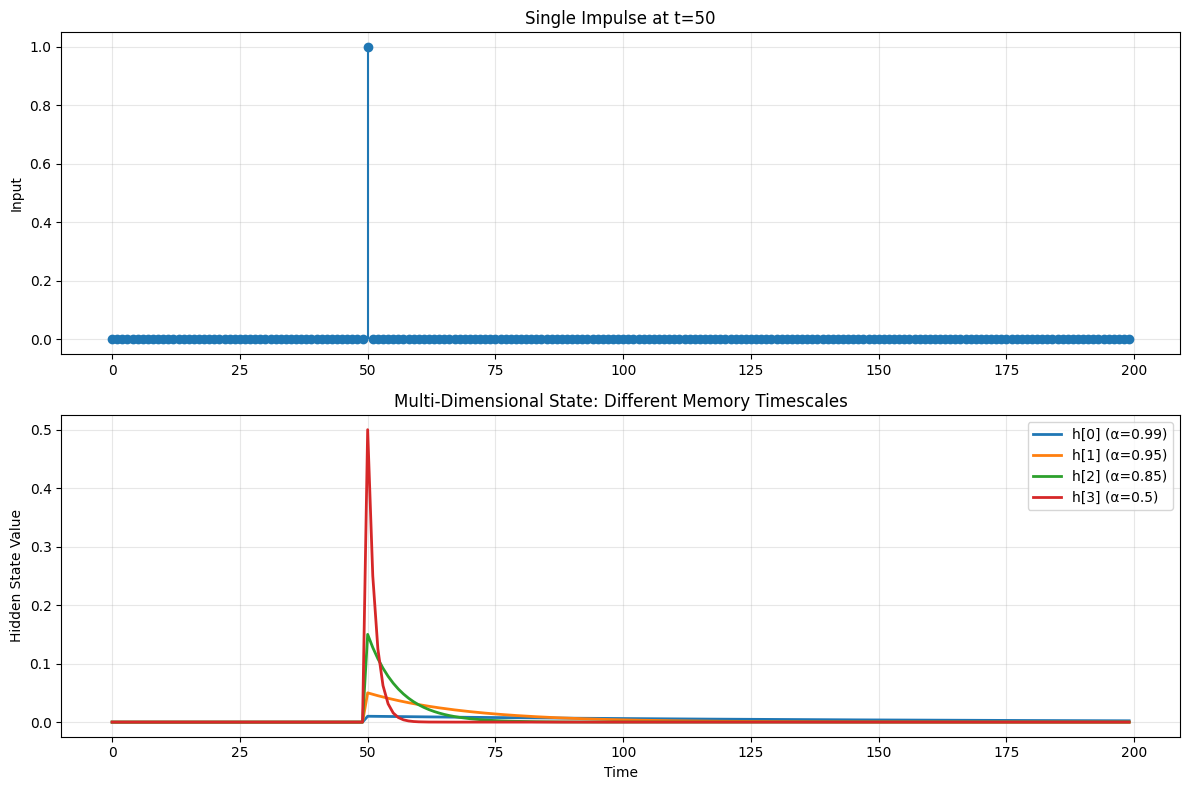

🎯 With N dimensions, we can remember:
   - Very recent context (short timescale)
   - Recent context (medium timescale)
   - Distant context (long timescale)
   All at once, in parallel!


In [6]:
# Simulate multi-dimensional state with different timescales
T = 200
x = np.zeros(T)
x[50] = 1.0

# Different alpha for each dimension
alphas = [0.99, 0.95, 0.85, 0.5]  # Very long to very short memory
N = len(alphas)

# Simulate each dimension
h_multi = np.zeros((T, N))
for i, alpha in enumerate(alphas):
    h_multi[:, i] = moving_average(x, alpha=alpha)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Input
axes[0].stem(x, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].set_ylabel('Input')
axes[0].set_title('Single Impulse at t=50')
axes[0].grid(True, alpha=0.3)

# Multiple dimensions
for i, alpha in enumerate(alphas):
    axes[1].plot(h_multi[:, i], label=f'h[{i}] (α={alpha})', linewidth=2)

axes[1].set_xlabel('Time')
axes[1].set_ylabel('Hidden State Value')
axes[1].set_title('Multi-Dimensional State: Different Memory Timescales')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 With N dimensions, we can remember:")
print("   - Very recent context (short timescale)")
print("   - Recent context (medium timescale)")
print("   - Distant context (long timescale)")
print("   All at once, in parallel!")

## 6. Comparing to What You Know

Let's connect Mamba to architectures you're already familiar with.

### Mamba vs LSTM vs Transformer

All three achieve "selective" memory, but differently:

| Aspect | Transformer | LSTM | Mamba |
|--------|------------|------|-------|
| **Selectivity** | Attention matrix | Forget/input gates | Input-dependent A,B,C |
| **Complexity** | O(L²) | O(L) | O(L) |
| **Parallelizable?** | Yes (training) | No | Yes (training)* |
| **Long-range** | Excellent | Poor | Good |
| **Training speed** | Fast (parallel) | Slow (sequential) | Fast (parallel scan) |
| **Inference** | O(L²) | O(1) per step | O(1) per step |

*Mamba uses a clever "parallel scan" algorithm for training

### LSTM gates vs Mamba selection

Both use input-dependent control, but Mamba is more flexible.

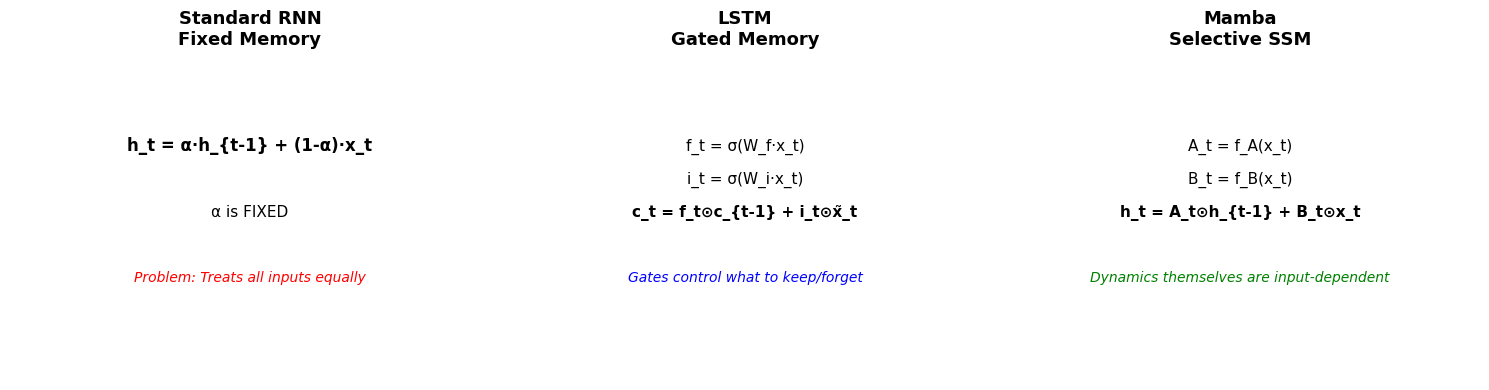


Key difference:
  LSTM: Gates control memory read/write
  Mamba: The entire recurrence dynamics adapt to input


In [7]:
# Visualize the conceptual difference
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Standard RNN: Fixed recurrence
axes[0].text(0.5, 0.7, 'h_t = α·h_{t-1} + (1-α)·x_t', 
            ha='center', fontsize=12, weight='bold')
axes[0].text(0.5, 0.5, '\nα is FIXED', ha='center', fontsize=11)
axes[0].text(0.5, 0.3, '\n\nProblem: Treats all inputs equally', 
            ha='center', fontsize=10, style='italic', color='red')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].axis('off')
axes[0].set_title('Standard RNN\nFixed Memory', fontsize=13, weight='bold')

# LSTM: Gated
axes[1].text(0.5, 0.7, 'f_t = σ(W_f·x_t)', ha='center', fontsize=11)
axes[1].text(0.5, 0.6, 'i_t = σ(W_i·x_t)', ha='center', fontsize=11)
axes[1].text(0.5, 0.5, 'c_t = f_t⊙c_{t-1} + i_t⊙x̃_t', ha='center', fontsize=11, weight='bold')
axes[1].text(0.5, 0.3, '\n\nGates control what to keep/forget', 
            ha='center', fontsize=10, style='italic', color='blue')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axis('off')
axes[1].set_title('LSTM\nGated Memory', fontsize=13, weight='bold')

# Mamba: Selective SSM
axes[2].text(0.5, 0.7, 'A_t = f_A(x_t)', ha='center', fontsize=11)
axes[2].text(0.5, 0.6, 'B_t = f_B(x_t)', ha='center', fontsize=11)
axes[2].text(0.5, 0.5, 'h_t = A_t⊙h_{t-1} + B_t⊙x_t', ha='center', fontsize=11, weight='bold')
axes[2].text(0.5, 0.3, '\n\nDynamics themselves are input-dependent', 
            ha='center', fontsize=10, style='italic', color='green')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].axis('off')
axes[2].set_title('Mamba\nSelective SSM', fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

print("\nKey difference:")
print("  LSTM: Gates control memory read/write")
print("  Mamba: The entire recurrence dynamics adapt to input")

## 7. Empirical Validation: Linear vs Quadratic

Let's measure the scaling ourselves.

### Implement minimal versions for benchmarking

In [8]:
def minimal_attention(x):
    """
    Minimal attention: just the O(L²) matmul.
    x: (batch, seq_len, d_model)
    """
    B, L, D = x.shape
    
    # Q, K, V (skip weight matrices for speed)
    Q, K, V = x, x, x
    
    # The expensive part: O(L²) attention matrix
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(D)  # (B, L, L)
    attn = F.softmax(scores, dim=-1)
    out = torch.matmul(attn, V)  # (B, L, D)
    
    return out

def minimal_mamba(x):
    """
    Minimal Mamba: just the O(L) recurrence.
    x: (batch, seq_len, d_model)
    """
    B, L, D = x.shape
    
    # Simple recurrence with fixed alpha (for speed)
    h = torch.zeros(B, D, device=x.device)
    outputs = []
    alpha = 0.9
    
    for t in range(L):
        h = alpha * h + (1 - alpha) * x[:, t, :]
        outputs.append(h)
    
    return torch.stack(outputs, dim=1)  # (B, L, D)

print("Functions defined for benchmarking")

Functions defined for benchmarking


### Benchmark both approaches

In [9]:
seq_lengths = CONFIG['seq_lengths']
d_model = CONFIG['d_model']
batch_size = 4

attention_times = []
mamba_times = []

print("Benchmarking Attention vs Mamba-style recurrence...")
print(f"Model dimension: {d_model}")
print()

for seq_len in seq_lengths:
    x = torch.randn(batch_size, seq_len, d_model, device=device)
    
    # Warmup
    for _ in range(3):
        _ = minimal_attention(x)
        _ = minimal_mamba(x)
    
    if device.type in ['cuda', 'mps']:
        torch.cuda.synchronize() if device.type == 'cuda' else torch.mps.synchronize()
    
    # Benchmark attention
    start = time.time()
    for _ in range(10):
        _ = minimal_attention(x)
    if device.type in ['cuda', 'mps']:
        torch.cuda.synchronize() if device.type == 'cuda' else torch.mps.synchronize()
    attn_time = (time.time() - start) / 10
    attention_times.append(attn_time)
    
    # Benchmark Mamba
    start = time.time()
    for _ in range(10):
        _ = minimal_mamba(x)
    if device.type in ['cuda', 'mps']:
        torch.cuda.synchronize() if device.type == 'cuda' else torch.mps.synchronize()
    mamba_time = (time.time() - start) / 10
    mamba_times.append(mamba_time)
    
    speedup = attn_time / mamba_time
    print(f"L={seq_len:5d}: Attention {attn_time*1000:6.2f}ms | Mamba {mamba_time*1000:6.2f}ms | Speedup {speedup:.2f}x")

print("\nBenchmarking complete!")

Benchmarking Attention vs Mamba-style recurrence...
Model dimension: 256



L=  128: Attention   0.22ms | Mamba   3.99ms | Speedup 0.05x
L=  256: Attention   0.27ms | Mamba   6.74ms | Speedup 0.04x


L=  512: Attention   0.75ms | Mamba  13.15ms | Speedup 0.06x


L= 1024: Attention   2.40ms | Mamba  26.17ms | Speedup 0.09x


L= 2048: Attention   7.61ms | Mamba  53.28ms | Speedup 0.14x

Benchmarking complete!


### Visualize the scaling difference

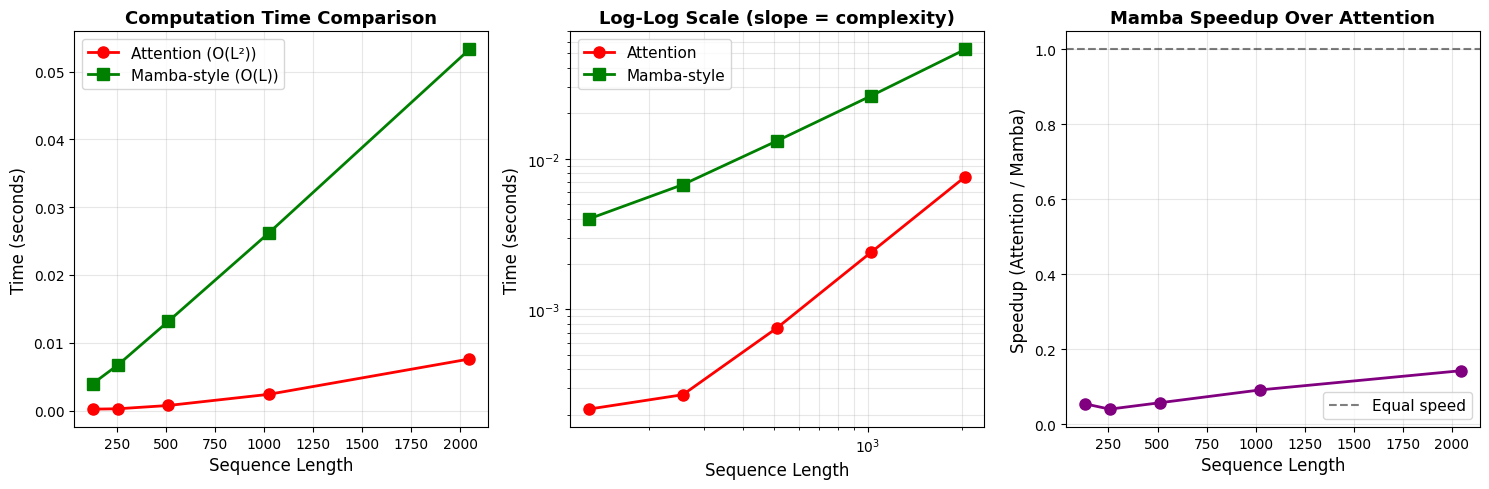


📊 Results:
   At L=128: 0.1x speedup
   At L=2048: 0.1x speedup

   Speedup grows with sequence length!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Linear scale
axes[0].plot(seq_lengths, attention_times, 'o-', label='Attention (O(L²))', 
            linewidth=2, markersize=8, color='red')
axes[0].plot(seq_lengths, mamba_times, 's-', label='Mamba-style (O(L))', 
            linewidth=2, markersize=8, color='green')
axes[0].set_xlabel('Sequence Length', fontsize=12)
axes[0].set_ylabel('Time (seconds)', fontsize=12)
axes[0].set_title('Computation Time Comparison', fontsize=13, weight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Log-log scale
axes[1].plot(seq_lengths, attention_times, 'o-', label='Attention', 
            linewidth=2, markersize=8, color='red')
axes[1].plot(seq_lengths, mamba_times, 's-', label='Mamba-style', 
            linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Sequence Length', fontsize=12)
axes[1].set_ylabel('Time (seconds)', fontsize=12)
axes[1].set_title('Log-Log Scale (slope = complexity)', fontsize=13, weight='bold')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, which='both')

# Speedup
speedups = [a/m for a, m in zip(attention_times, mamba_times)]
axes[2].plot(seq_lengths, speedups, 'o-', linewidth=2, markersize=8, color='purple')
axes[2].axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Equal speed')
axes[2].set_xlabel('Sequence Length', fontsize=12)
axes[2].set_ylabel('Speedup (Attention / Mamba)', fontsize=12)
axes[2].set_title('Mamba Speedup Over Attention', fontsize=13, weight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Results:")
print(f"   At L={seq_lengths[0]}: {speedups[0]:.1f}x speedup")
print(f"   At L={seq_lengths[-1]}: {speedups[-1]:.1f}x speedup")
print(f"\n   Speedup grows with sequence length!")

## 8. The Training vs Inference Distinction

Mamba has a clever trick: **different algorithms for training vs inference**.

### Training: Parallel Scan

During training, we have the full sequence and can parallelize:

```
Sequential (what we've shown):
h_1 = A_1·h_0 + B_1·x_1
h_2 = A_2·h_1 + B_2·x_2  # Must wait for h_1
h_3 = A_3·h_2 + B_3·x_3  # Must wait for h_2
...

Parallel Scan (clever!): 
All h_t computed in O(log L) parallel steps instead of O(L)
```

This is like how you can compute `sum([1,2,3,4,5,6,7,8])` in parallel:
```
Step 1: [1+2, 3+4, 5+6, 7+8] = [3, 7, 11, 15]
Step 2: [3+7, 11+15] = [10, 26]
Step 3: [10+26] = [36]
```
Only 3 steps instead of 8!

### Inference: Sequential Recurrence

During inference (autoregressive generation), we process one token at a time:

```python
# Generate token by token
h = initial_state
for token in generated_tokens:
    A_t, B_t, C_t = compute_selective_params(token)
    h = A_t * h + B_t * token  # O(1) - just update state!
    next_token = predict(C_t @ h)
```

Compare to Transformer:
```python
# Transformer must recompute attention over ALL previous tokens
for token in generated_tokens:
    # Must attend to all previous tokens: O(L²)!
    next_token = attention(token, all_previous_tokens)
```

### Summary: Best of Both Worlds

| Stage | Transformer | Mamba |
|-------|-------------|-------|
| **Training** | O(L²) attention | O(L) with parallel scan |
| **Inference (per token)** | O(L) (attend to all previous) | O(1) (just update state) |
| **Memory** | Must store all tokens | Just store fixed-size state |

Mamba is especially advantageous for:
- Long sequence training
- Fast autoregressive generation
- Streaming applications (process input as it arrives)

## 9. When to Use What?

Now that you understand the core ideas, when should you use each?

### Decision Guide

**Use Transformers when:**
- ✅ Sequence length < 4K tokens
- ✅ Need bidirectional context (BERT-style)
- ✅ Want to use pre-trained models (more available)
- ✅ Task requires fine-grained token interactions

**Use Mamba when:**
- ✅ Very long sequences (>8K tokens)
- ✅ Memory constrained
- ✅ Need fast inference
- ✅ Streaming/online processing
- ✅ Training from scratch anyway

**Hybrid approach (emerging):**
- Use Mamba for long-range context
- Use attention for fine-grained local interactions
- Example: Mamba blocks + occasional attention layer

### Concrete examples

Let's think about real tasks:

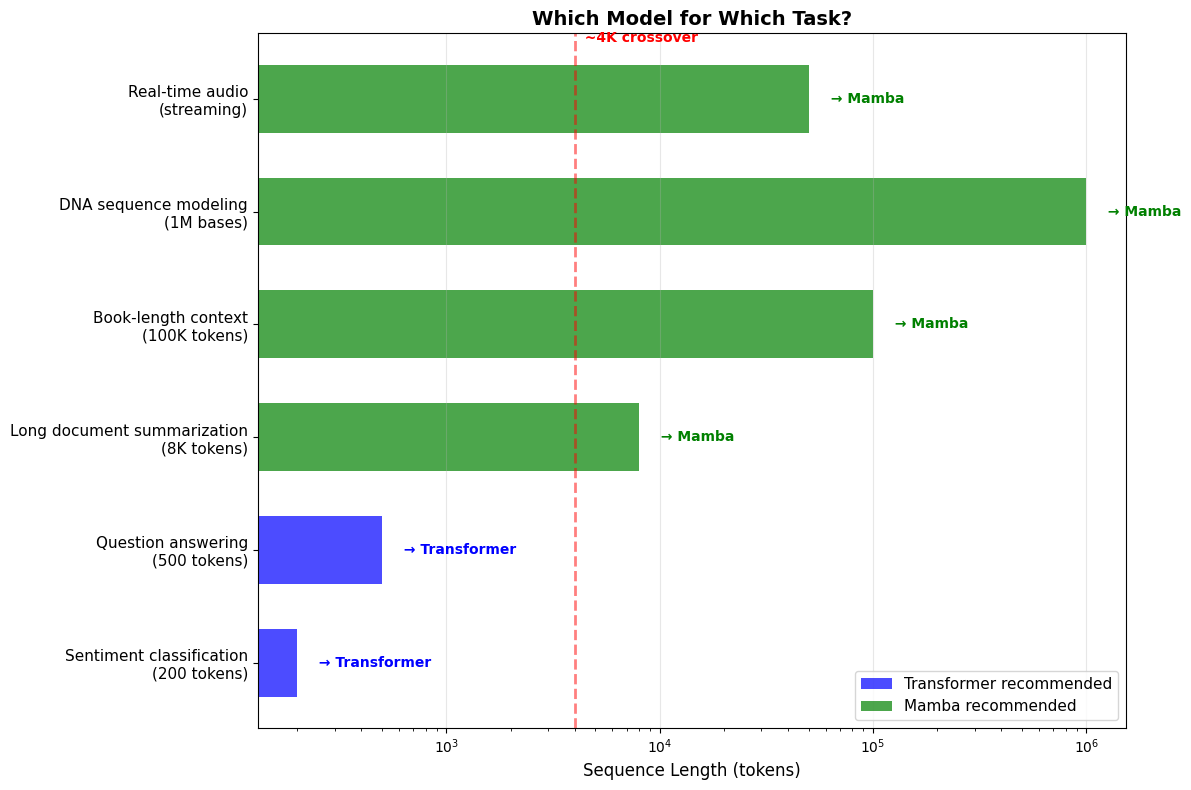


🎯 Rule of thumb:
   < 2K tokens: Transformer is fine
   2-8K tokens: Both work, consider trade-offs
   > 8K tokens: Mamba has clear advantages


In [11]:
# Create visualization of task recommendations
fig, ax = plt.subplots(figsize=(12, 8))

tasks = [
    "Sentiment classification\n(200 tokens)",
    "Question answering\n(500 tokens)",
    "Long document summarization\n(8K tokens)",
    "Book-length context\n(100K tokens)",
    "DNA sequence modeling\n(1M bases)",
    "Real-time audio\n(streaming)",
]

seq_lengths_tasks = [200, 500, 8000, 100000, 1000000, 50000]  # Approximate
recommendations = [
    "Transformer", "Transformer", "Mamba", "Mamba", "Mamba", "Mamba"
]

colors = ['blue' if r == 'Transformer' else 'green' for r in recommendations]

y_pos = np.arange(len(tasks))
bars = ax.barh(y_pos, seq_lengths_tasks, color=colors, alpha=0.7, height=0.6)

# Add task labels
ax.set_yticks(y_pos)
ax.set_yticklabels(tasks, fontsize=11)
ax.set_xlabel('Sequence Length (tokens)', fontsize=12)
ax.set_xscale('log')
ax.set_title('Which Model for Which Task?', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add recommendation labels
for i, (length, rec) in enumerate(zip(seq_lengths_tasks, recommendations)):
    ax.text(length * 1.2, i, f' → {rec}', va='center', fontsize=10, weight='bold',
           color='blue' if rec == 'Transformer' else 'green')

# Add vertical line at crossover point (~4K)
ax.axvline(x=4000, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax.text(4000, len(tasks) - 0.5, '  ~4K crossover', color='red', fontsize=10, weight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.7, label='Transformer recommended'),
    Patch(facecolor='green', alpha=0.7, label='Mamba recommended')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

print("\n🎯 Rule of thumb:")
print("   < 2K tokens: Transformer is fine")
print("   2-8K tokens: Both work, consider trade-offs")
print("   > 8K tokens: Mamba has clear advantages")

## 10. Key Takeaways

If you remember nothing else, remember these:

### The Core Insight
**Mamba makes recurrence parameters (A, B, C) depend on the input.**

This gives you:
- ✅ Selectivity (like attention)
- ✅ Linear complexity (like RNNs)
- ✅ Content-aware memory

### The Key Comparison
```
Transformer: "Look at everything" (O(L²))
Old RNN:     "Fixed memory rule" (O(L), but not selective)
Mamba:       "Adaptive memory rule" (O(L), AND selective!)
```

### Why It Works
1. **Multi-dimensional state** captures multiple timescales
2. **Input-dependent parameters** provide selectivity
3. **Parallel scan** makes training fast
4. **Sequential inference** makes generation fast

### The Big Picture
- Transformers aren't going away (they're great for many tasks)
- Mamba opens new possibilities (very long sequences)
- Future is likely **hybrid** (combining both)

### Next Steps
If you want to dive deeper:
1. Read the Mamba paper (you'll understand it now!)
2. Check out the `mamba-state-space-models.ipynb` notebook for mathematical details
3. Try implementing a simple Mamba layer
4. Experiment with hybrid architectures

**You now understand the core idea that makes Mamba work! 🎉**